# 03 - Hardware experiment (offline, SIMULATED)

**Important.** This notebook runs the *same code path* as a real IBM/PINQ2 job, but against an IBM **fake backend** (a local noisy simulation). Results are simulated, not from a quantum computer. For real hardware see the README (`python -m scripts.run_hardware submit ...` with your token in `.env`).

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
QUICK = True   # False = bigger budgets (slower, tighter error bars)
import tempfile
from pathlib import Path
from src import hardware as hw
from src.noise import get_fake_backend
backend = get_fake_backend("fake_quebec")
out = Path(tempfile.mkdtemp())
shots = 2000 if QUICK else 8192
run_dir, job = hw.submit(3, 3, shots, backend=backend, simulated=True, out_root=out, seed_simulator=1)
hw.fetch(run_dir, job=job, wait=True)

[submit] backend=fake_quebec d=3 rounds=3 shots=2000 chain=[38, 39, 40, 41, 42]
[submit] fake_quebec: chain=[38, 39, 40, 41, 42] median 2q err=0.0075 median readout err=0.0066 median T1=406us T2=258us
[submit] transpiled: depth=43 ops={'rz': 60, 'sx': 30, 'ecr': 12, 'barrier': 10, 'x': 9, 'measure': 9, 'reset': 4}


[submit] JOB ID: fa63b635-9ff1-4f71-bace-aea55ca680a0   <-- saved to disk now


[fetch] job fa63b635-9ff1-4f71-bace-aea55ca680a0: DONE
[fetch] saved 2000 shots x 9 bits to /tmp/tmp0wenycbk/fake_quebec_d3_r3_fa63b635


True

In [2]:
df = hw.analyze_run(run_dir, nn_steps=300 if QUICK else 3000, stim_shots=50_000, log=print)
df[["source", "decoder", "shots", "errors", "ler", "ler_lo", "ler_hi"]]

[analyze] training the neural decoder on the Stim approximation (300 steps)


,source,decoder,shots,errors,ler,ler_lo,ler_hi
0,Aer (this run),mwpm_matched,2000,3,0.00150,0.000510,0.004401
1,Aer (this run),nn,2000,4,0.00200,0.000778,0.005131
2,Aer (this run),greedy,2000,5,0.00250,0.001068,0.005839
3,Stim approx.,mwpm_matched,50000,140,0.00280,0.002373,0.003303
4,Stim approx.,nn,50000,136,0.00272,0.002300,0.003216
5,Stim approx.,greedy,50000,159,0.00318,0.002723,0.003713


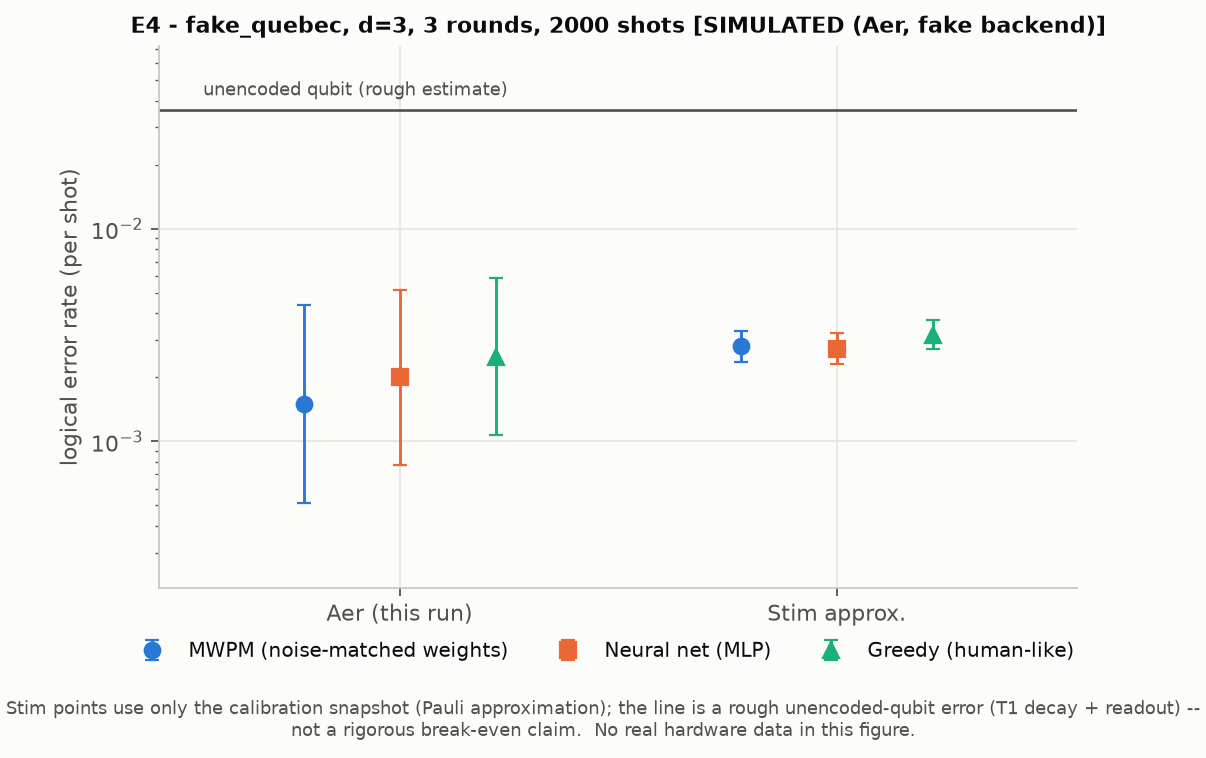

In [3]:
from IPython.display import Image
hw.plot_run(run_dir, df)
Image(filename=str(run_dir / "fig_hardware_vs_sim.png"))

**Reading the figure.** Each dot is a logical error rate with a 95% interval. `Aer` = simulation with the backend's noise model; `Stim approx.` = a simpler model built only from the calibration numbers. A gap between them is the *approximation error*, and on real hardware a further gap appears between simulation and reality.